# PCA 차원 축소 및 특성 융합
- 추출된 768차원의 KcBERT 임베딩은 다른 메타데이터(4차원)에 비해 차원이 지나치게 커서 모델 학습 시 불균형을 초래할 수 있다.
- 주성분 분석(PCA)을 통해 텍스트 임베딩의 차원을 축소한다.
- 축소된 텍스트 피처와 정규화된 메타데이터를 결합(Fusion)하여 최종 학습용 데이터셋(X, y)을 구축한다.

### 라이브러리 로드
- 차원 축소 및 데이터 스케일링을 위한 scikit-learn 패키지를 임포트한다.
  1. sklearn.decomposition.PCA: 주성분 분석(차원 축소)
  2. sklearn.preprocessing.StandardScaler: 데이터 표준화(정규화)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#추가됨
from sklearn.model_selection import train_test_split

### 데이터 로드
- 이전 단계에서 저장한 `reviews_with_embeddings.csv` 파일을 불러온다.
- 768개의 KcBERT 임베딩 컬럼(`kcbert_0` ~ `kcbert_767`)만 별도로 추출하여 행렬 형태로 준비한다.

In [ ]:
#df = pd.read_csv('reviews_embeddings_extract.csv')

# 텍스트 임베딩 컬럼들만 따로 분리 (kcbert_0 ~ kcbert_767)
#emb_cols = [f'kcbert_{i}' for i in range(768)]
#kcbert_features = df[emb_cols].values

#print(f"입력 데이터 형태: {kcbert_features.shape}")
#### 
df = pd.read_csv('reviews_embeddings_extract.csv')

# KcBERT 임베딩 컬럼
emb_cols = [f'kcbert_{i}' for i in range(768)]

# 메타데이터 컬럼
meta_cols = ['rating', 'text_length', 'emoji_count', 'photo_count']

# 입력 데이터 분리
X_emb = df[emb_cols].values
X_meta = df[meta_cols].values
y = df['label'].values

# 1차 분할: train 70%, temp 30%
X_emb_train, X_emb_temp, X_meta_train, X_meta_temp, y_train, y_temp = train_test_split(
    X_emb,
    X_meta,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: validation 15%, test 15%
X_emb_val, X_emb_test, X_meta_val, X_meta_test, y_val, y_test = train_test_split(
    X_emb_temp,
    X_meta_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"전체 임베딩 형태: {X_emb.shape}")
print(f"학습 임베딩 형태: {X_emb_train.shape}")
print(f"검증 임베딩 형태: {X_emb_val.shape}")
print(f"테스트 임베딩 형태: {X_emb_test.shape}")

입력 데이터 형태: (8840, 768)


/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_52368/3865036701.py:1: DtypeWarning: Columns (0: store_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('reviews_embeddings_extract.csv')


### PCA 차원 축소 및 시각화
- 원본 데이터의 정보량(분산)을 90% 보존하는 수준(`n_components=0.90`)으로 차원을 축소한다.
- 축소 전후의 누적 설명 분산 비율(Cumulative Explained Variance)을 시각화하여, 적절한 차원으로 압축되었는지 확인한다.

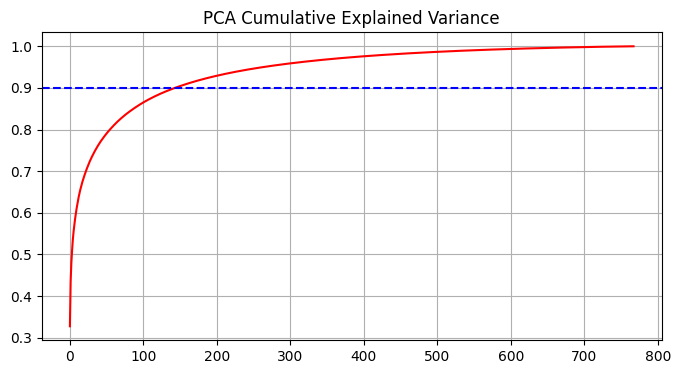

차원 축소 전 데이터 형태: (8840, 768)
차원 축소 후 데이터 형태: (8840, 144)


In [ ]:
# 정보량 90% 보존하는 차원으로 축소
# pca = PCA(n_components=0.90, random_state=42)
# pca_features = pca.fit_transform(kcbert_features)

# 시각화: 누적 설명 분산 확인 (교수님 제출용)
# pca_full = PCA().fit(kcbert_features)
# plt.figure(figsize=(8, 4))
# plt.plot(np.cumsum(pca_full.explained_variance_ratio_), color='red')
# plt.axhline(y=0.9, color='blue', linestyle='--')
# plt.title('PCA Cumulative Explained Variance')
# plt.grid(True)
# plt.show()

# print(f"차원 축소 전 데이터 형태: {kcbert_features.shape}")
# print(f"차원 축소 후 데이터 형태: {pca_features.shape}")

#####
# 학습 데이터 기준으로만 PCA fit
pca = PCA(n_components=0.90, random_state=42)

X_emb_train_pca = pca.fit_transform(X_emb_train)
X_emb_val_pca = pca.transform(X_emb_val)
X_emb_test_pca = pca.transform(X_emb_test)

# 시각화도 학습 데이터 기준으로만 확인
pca_full = PCA().fit(X_emb_train)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), color='red')
plt.axhline(y=0.9, color='blue', linestyle='--')
plt.title('PCA Cumulative Explained Variance - Train Data')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

print(f"차원 축소 전 학습 데이터 형태: {X_emb_train.shape}")
print(f"차원 축소 후 학습 데이터 형태: {X_emb_train_pca.shape}")
print(f"차원 축소 후 검증 데이터 형태: {X_emb_val_pca.shape}")
print(f"차원 축소 후 테스트 데이터 형태: {X_emb_test_pca.shape}")
print(f"PCA 선택 차원 수: {pca.n_components_}")

### 메타데이터 정규화 (StandardScaler)
- 메타데이터(별점, 텍스트 길이, 이모지 개수, 사진 개수)의 단위와 스케일이 서로 다르므로 표준화(평균 0, 표준편차 1)를 진행한다.
- 정규화를 통해 모델이 특정 메타데이터 컬럼에 과적합되거나 편향되는 것을 방지한다.

In [ ]:
# 별점, 글자 수, 이모지 수, 사진 수
# meta_cols = ['rating', 'text_length', 'emoji_count', 'photo_count']

# StandardScaler 객체 생성 및 적용
# scaler = StandardScaler()
# scaled_metadata = scaler.fit_transform(df[meta_cols])

# print(f"스케일링 전 메타데이터 예시 (첫 리뷰):\n{df[meta_cols].iloc[0].values}")
# print(f"스케일링 후 메타데이터 예시 (첫 리뷰):\n{scaled_metadata[0]}")
# print(f"메타데이터 형태: {scaled_metadata.shape}")

#### 
# 학습 데이터 기준으로만 StandardScaler fit
scaler = StandardScaler()

X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_val_scaled = scaler.transform(X_meta_val)
X_meta_test_scaled = scaler.transform(X_meta_test)

print(f"스케일링 전 학습 메타데이터 예시:\n{X_meta_train[0]}")
print(f"스케일링 후 학습 메타데이터 예시:\n{X_meta_train_scaled[0]}")
print(f"학습 메타데이터 형태: {X_meta_train_scaled.shape}")
print(f"검증 메타데이터 형태: {X_meta_val_scaled.shape}")
print(f"테스트 메타데이터 형태: {X_meta_test_scaled.shape}")

스케일링 전 메타데이터 예시 (첫 리뷰):
[ 1. 16.  0.  0.]
스케일링 후 메타데이터 예시 (첫 리뷰):
[-7.61992474 -0.67362086 -0.17838864 -1.18844507]
메타데이터 형태: (8840, 4)


### 특성 융합 (Feature Fusion) 및 정답지 추가
- 축소된 PCA 임베딩(텍스트 문맥 정보)과 정규화된 메타데이터(사용자 행동 정보)를 수평 결합(`np.hstack`)한다.
- 결합된 피처들을 `feat_0`, `feat_1` 등의 컬럼명으로 명명하고, 메타데이터 컬럼명은 직관적으로 변경한다.
- 모델이 예측해야 할 최종 정답지인 `label` 컬럼을 `target_label`로 추가한다.

In [ ]:
# PCA 임베딩(문맥)과 정규화된 메타데이터(행동)를 수평 결합 (hstack)
# X_final = np.hstack([pca_features, scaled_metadata])
# y_final = df['label'].values

# column_names = [f'feat_{i}' for i in range(X_final.shape[1])]
# df_final = pd.DataFrame(X_final, columns=column_names)

# 정답지(label) 컬럼 추가
# df_final['target_label'] = y_final

# df_final = df_final.rename(columns={
#     'feat_144': 'meta_rating',
  #   'feat_145': 'meta_text_length',
    # 'feat_146': 'meta_emoji_count',
    # 'feat_147': 'meta_photo_count'
# })

#  print(f"결합된 최종 CSV 데이터프레임 형태: {df_final.shape}")
#  df_final.head()

# PCA 임베딩과 정규화된 메타데이터 결합
X_train_final = np.hstack([X_emb_train_pca, X_meta_train_scaled])
X_val_final = np.hstack([X_emb_val_pca, X_meta_val_scaled])
X_test_final = np.hstack([X_emb_test_pca, X_meta_test_scaled])

# PCA 차원 수 확인
pca_dim = X_emb_train_pca.shape[1]

# 컬럼명 생성
column_names = [f'feat_{i}' for i in range(X_train_final.shape[1])]

df_train_final = pd.DataFrame(X_train_final, columns=column_names)
df_val_final = pd.DataFrame(X_val_final, columns=column_names)
df_test_final = pd.DataFrame(X_test_final, columns=column_names)

# 정답 label 추가
df_train_final['target_label'] = y_train
df_val_final['target_label'] = y_val
df_test_final['target_label'] = y_test

# 마지막 4개 컬럼명을 메타데이터 이름으로 변경
rename_dict = {
    f'feat_{pca_dim}': 'meta_rating',
    f'feat_{pca_dim + 1}': 'meta_text_length',
    f'feat_{pca_dim + 2}': 'meta_emoji_count',
    f'feat_{pca_dim + 3}': 'meta_photo_count'
}

df_train_final = df_train_final.rename(columns=rename_dict)
df_val_final = df_val_final.rename(columns=rename_dict)
df_test_final = df_test_final.rename(columns=rename_dict)

print(f"PCA 차원 수: {pca_dim}")
print(f"최종 학습 데이터프레임 형태: {df_train_final.shape}")
print(f"최종 검증 데이터프레임 형태: {df_val_final.shape}")
print(f"최종 테스트 데이터프레임 형태: {df_test_final.shape}")

df_train_final.head()

결합된 최종 CSV 데이터프레임 형태: (8840, 149)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_139,feat_140,feat_141,feat_142,feat_143,meta_rating,meta_text_length,meta_emoji_count,meta_photo_count,target_label
0,-6.899613,-16.433576,-7.200539,4.419363,-3.112676,2.731247,-1.493783,-0.567354,1.748197,2.948480,...,-0.113886,-0.060121,0.004946,0.547325,-0.398119,-7.619925,-0.673621,-0.178389,-1.188445,0
1,10.812185,-3.786238,-3.215839,1.934517,2.479144,2.090086,-1.783381,1.932198,0.207977,-3.262855,...,0.211775,-0.981352,-0.844774,-1.339891,-1.181437,-7.619925,0.552610,-0.178389,1.423977,0
2,8.222048,4.569485,-2.979760,0.374183,1.213934,-0.086695,-1.435596,1.072465,1.605158,-0.381534,...,0.720942,-0.070365,-0.567284,-0.241996,-0.588075,-7.619925,1.546851,-0.178389,2.730188,0
3,15.972075,-3.088499,0.472461,3.677950,2.164908,0.199699,-2.403853,2.044947,-0.038854,-1.396961,...,-0.281044,-0.929061,0.027727,-0.552655,-0.040260,-7.619925,1.712558,-0.178389,0.117766,0
4,13.156158,2.773020,0.763575,0.391318,1.373999,1.710965,-1.966300,-0.282502,0.539488,0.018832,...,0.522346,-0.344713,-0.457865,0.106760,0.071827,-7.619925,2.010830,-0.178389,-1.188445,0


### 최종 데이터 산출

In [ ]:
# output_csv = 'final_hybrid_data.csv'
# df_final.to_csv(output_csv, index=False, encoding='utf-8-sig')

# print(f"최종 결과가 {output_csv}로 저장되었습니다.")
###
train_output_csv = 'final_hybrid_train.csv'
val_output_csv = 'final_hybrid_val.csv'
test_output_csv = 'final_hybrid_test.csv'

df_train_final.to_csv(train_output_csv, index=False, encoding='utf-8-sig')
df_val_final.to_csv(val_output_csv, index=False, encoding='utf-8-sig')
df_test_final.to_csv(test_output_csv, index=False, encoding='utf-8-sig')

print(f"학습 데이터가 {train_output_csv}로 저장되었습니다.")
print(f"검증 데이터가 {val_output_csv}로 저장되었습니다.")
print(f"테스트 데이터가 {test_output_csv}로 저장되었습니다.")

최종 결과가 final_hybrid_data.csv로 저장되었습니다.
